# FinLend — Análise estatística da inadimplência

**Parte 2:** o Head de Risco afirma que a inadimplência está subindo porque a empresa
está aprovando muitos empréstimos de Grade D e E. Este notebook investiga essa
explicação e examina o que mais pode estar associado à alta.

## Decisões de escopo

Restringi a análise a empréstimos de **36 meses** originados em **2014–2015** porque
essas safras estavam praticamente resolvidas no snapshot de dezembro de 2018. Em safras
mais recentes, grande parte dos contratos ainda estaria ativa; analisar somente os
poucos contratos já resolvidos poderia produzir uma amostra não representativa e
subestimar ou distorcer a inadimplência final.

A fonte é a camada Gold (`analysis_cohort.parquet`), a mesma coorte usada no dashboard
de Self-Service BI, para manter uma única definição de métricas entre os entregáveis.

| Item | Definição |
|---|---|
| Fonte | Gold — `analysis_cohort.parquet` |
| Originação | jan/2014 – dez/2015 |
| Prazo | 36 meses |
| População | Contratos com desfecho conhecido |
| Inadimplência | `Charged Off`, `Default` e equivalentes de política |


## 0. Setup


In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

GOLD_FILE = PROJECT_ROOT / "data" / "gold" / "analysis_cohort.parquet"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"

if not GOLD_FILE.exists():
    raise FileNotFoundError(
        f"Gold dataset not found: {GOLD_FILE}. "
        "Run the notebook from the project root or notebooks directory."
    )

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [2]:
df = pd.read_parquet(GOLD_FILE)

required_cols = [
    "loan_id",
    "issue_year",
    "issue_quarter",
    "grade",
    "grade_group",
    "is_grade_de",
    "purpose",
    "loan_amount",
    "interest_rate_pct",
    "annual_income",
    "debt_to_income_ratio",
    "fico_score_avg",
    "verification_status",
    "default_flag",
    "dti_band",
]

missing = [c for c in required_cols if c not in df.columns]
assert not missing, f"Missing columns: {missing}"
assert df["loan_id"].is_unique
assert df["default_flag"].isin([0, 1]).all()

df = df.sort_values(["issue_quarter", "loan_id"]).reset_index(drop=True)
df["period"] = np.where(df["issue_year"] == 2014, "2014", "2015")

print(f"Contratos: {len(df):,}")
print(f"Inadimplentes: {int(df['default_flag'].sum()):,}")
print(f"Taxa de inadimplência: {100 * df['default_flag'].mean():.2f}%")
print(f"Trimestres: {sorted(df['issue_quarter'].unique())}")
df.head()


Contratos: 445,596
Inadimplentes: 64,447
Taxa de inadimplência: 14.46%
Trimestres: ['2014-Q1', '2014-Q2', '2014-Q3', '2014-Q4', '2015-Q1', '2015-Q2', '2015-Q3', '2015-Q4']


,loan_id,record_hash,issue_date,issue_year,issue_quarter,loan_amount,funded_amount,term_months,interest_rate_pct,installment,...,credit_history_years,revolving_utilization_pct,delinquencies_2y,open_accounts,total_accounts,mortgage_accounts,public_record_bankruptcies,default_flag,outcome,period
0,10004568,94e5be5f4640577bb8a300950f68d36f,2014-01-01,2014,2014-Q1,"12,000.0000","12,000.0000",36,7.6200,373.9400,...,19,79.0000,0,20,38,3,0,0,Fully paid,2014
1,10004652,558731134188fec972f75c83777e66d0,2014-01-01,2014,2014-Q1,"5,250.0000","5,250.0000",36,19.2200,193.0300,...,12,73.7000,1,12,21,1,1,1,Defaulted,2014
2,10004654,21ce002e70301373fa5b92e6765d1ac2,2014-01-01,2014,2014-Q1,"6,700.0000","6,700.0000",36,11.9900,222.5100,...,35,65.3000,0,28,63,6,0,0,Fully paid,2014
3,10004703,dab658032b075130871ae88ccaf58ed2,2014-01-01,2014,2014-Q1,"25,050.0000","25,050.0000",36,19.2200,921.0300,...,9,67.0000,0,7,22,1,0,0,Fully paid,2014
4,10024707,e0ea540663c9e52dca2fcbcc5e0777bc,2014-01-01,2014,2014-Q1,"6,000.0000","6,000.0000",36,14.4700,206.4400,...,10,68.1000,0,8,11,1,0,0,Fully paid,2014


## 1. Análise exploratória da inadimplência

**Pergunta.** A inadimplência realmente aumentou na coorte? Se sim, isso veio acompanhado
de maior participação de Grades D/E, ou o risco mudou *dentro* das faixas já existentes?

**Método.** Comparo a evolução trimestral da taxa de inadimplência com a participação de
D/E e, em seguida, a inadimplência condicional a cada grupo de grade (D/E vs demais),
além do mix e da taxa por grade entre 2014 e 2015.


In [3]:
quarterly = (
    df.groupby("issue_quarter", as_index=False)
    .agg(
        total_loans=("loan_id", "size"),
        default_rate=("default_flag", "mean"),
        grade_de_share=("is_grade_de", "mean"),
        avg_interest_rate=("interest_rate_pct", "mean"),
        avg_dti=("debt_to_income_ratio", "mean"),
        avg_fico=("fico_score_avg", "mean"),
    )
)

de_rates = (
    df.groupby(["issue_quarter", "is_grade_de"], as_index=False)
    .agg(default_rate=("default_flag", "mean"))
    .pivot(index="issue_quarter", columns="is_grade_de", values="default_rate")
    .rename(columns={False: "other_default_rate", True: "de_default_rate"})
    .reset_index()
)

quarterly = quarterly.merge(de_rates, on="issue_quarter")
quarterly["default_rate_pct"] = 100 * quarterly["default_rate"]
quarterly["grade_de_share_pct"] = 100 * quarterly["grade_de_share"]
quarterly["de_default_rate_pct"] = 100 * quarterly["de_default_rate"]
quarterly["other_default_rate_pct"] = 100 * quarterly["other_default_rate"]

quarterly.to_csv(TABLES_DIR / "eda_quarterly_metrics.csv", index=False)
quarterly[
    [
        "issue_quarter",
        "total_loans",
        "default_rate_pct",
        "grade_de_share_pct",
        "de_default_rate_pct",
        "other_default_rate_pct",
    ]
]


,issue_quarter,total_loans,default_rate_pct,grade_de_share_pct,de_default_rate_pct,other_default_rate_pct
0,2014-Q1,34074,12.8661,14.9263,22.2572,11.2184
1,2014-Q2,37881,13.5450,16.7762,22.3289,11.7744
2,2014-Q3,40595,13.6298,18.4826,21.4981,11.8458
3,2014-Q4,50020,14.5282,17.2571,26.5755,12.0156
4,2015-Q1,56568,14.8335,16.4528,27.0979,12.4183
5,2015-Q2,64222,15.3810,16.6734,27.7456,12.9069
6,2015-Q3,73567,14.5785,15.3221,26.7566,12.3750
7,2015-Q4,88669,14.8169,12.2557,29.1617,12.8133


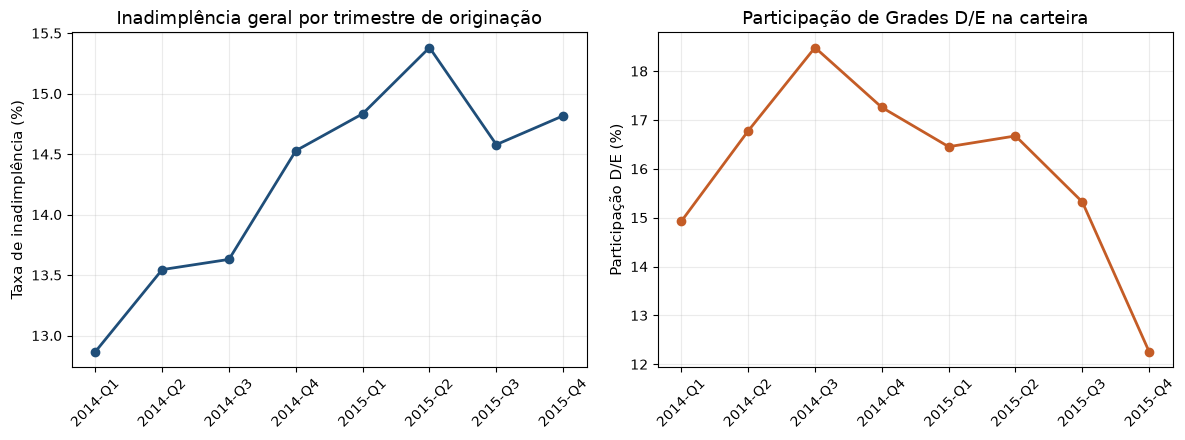

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

axes[0].plot(
    quarterly["issue_quarter"],
    quarterly["default_rate_pct"],
    marker="o",
    color="#1f4e79",
    linewidth=2,
)
axes[0].set_title("Inadimplência geral por trimestre de originação")
axes[0].set_ylabel("Taxa de inadimplência (%)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(
    quarterly["issue_quarter"],
    quarterly["grade_de_share_pct"],
    marker="o",
    color="#c45c26",
    linewidth=2,
)
axes[1].set_title("Participação de Grades D/E na carteira")
axes[1].set_ylabel("Participação D/E (%)")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_default_vs_de_share.png", dpi=150, bbox_inches="tight")
plt.show()


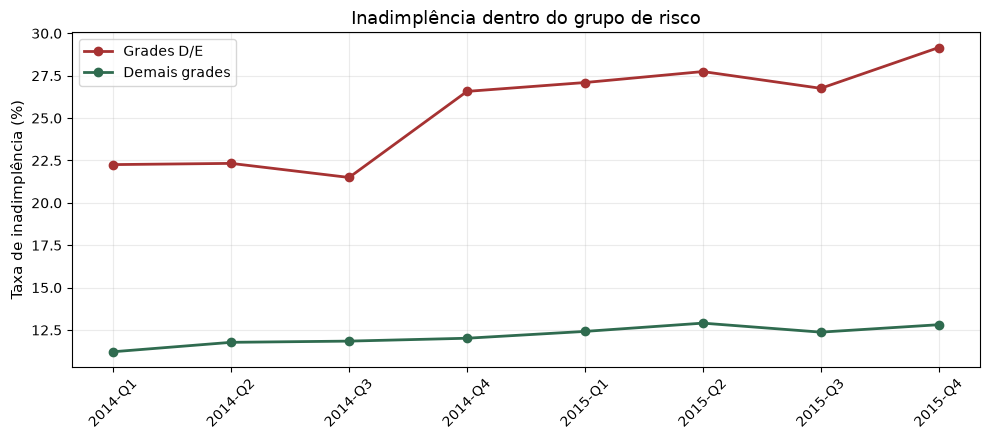

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(
    quarterly["issue_quarter"],
    quarterly["de_default_rate_pct"],
    marker="o",
    label="Grades D/E",
    color="#a63232",
    linewidth=2,
)
ax.plot(
    quarterly["issue_quarter"],
    quarterly["other_default_rate_pct"],
    marker="o",
    label="Demais grades",
    color="#2f6b4f",
    linewidth=2,
)
ax.set_title("Inadimplência dentro do grupo de risco")
ax.set_ylabel("Taxa de inadimplência (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "02_default_within_grade_groups.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


In [6]:
default_by_grade = (
    df.groupby(["period", "grade"], as_index=False)
    .agg(
        total_loans=("loan_id", "size"),
        default_rate=("default_flag", "mean"),
        avg_interest_rate=("interest_rate_pct", "mean"),
        avg_dti=("debt_to_income_ratio", "mean"),
    )
)
default_by_grade["default_rate_pct"] = 100 * default_by_grade["default_rate"]

share_by_grade = (
    df.groupby(["period", "grade"])
    .size()
    .div(df.groupby("period").size())
    .rename("portfolio_share")
    .reset_index()
)
share_by_grade["portfolio_share_pct"] = 100 * share_by_grade["portfolio_share"]

grade_summary = default_by_grade.merge(
    share_by_grade[["period", "grade", "portfolio_share_pct"]],
    on=["period", "grade"],
)

wide = grade_summary.pivot(index="grade", columns="period")
eda_grade = pd.DataFrame(
    {
        "share_2014_pct": wide[("portfolio_share_pct", "2014")],
        "share_2015_pct": wide[("portfolio_share_pct", "2015")],
        "default_2014_pct": wide[("default_rate_pct", "2014")],
        "default_2015_pct": wide[("default_rate_pct", "2015")],
        "rate_2014_pct": wide[("avg_interest_rate", "2014")],
        "rate_2015_pct": wide[("avg_interest_rate", "2015")],
        "dti_2014": wide[("avg_dti", "2014")],
        "dti_2015": wide[("avg_dti", "2015")],
    }
)
eda_grade["delta_default_pp"] = (
    eda_grade["default_2015_pct"] - eda_grade["default_2014_pct"]
)
eda_grade["delta_rate_pp"] = (
    eda_grade["rate_2015_pct"] - eda_grade["rate_2014_pct"]
)
eda_grade["delta_share_pp"] = (
    eda_grade["share_2015_pct"] - eda_grade["share_2014_pct"]
)
eda_grade = eda_grade.reindex(list("ABCDEFG"))
eda_grade.to_csv(TABLES_DIR / "eda_grade_period_comparison.csv")
eda_grade.round(2)


,share_2014_pct,share_2015_pct,default_2014_pct,default_2015_pct,rate_2014_pct,rate_2015_pct,dti_2014,dti_2015,delta_default_pp,delta_rate_pp,delta_share_pp
grade,,,,,,,,,,,
A,21.7300,24.7700,5.3800,5.4200,7.4500,6.9000,15.8100,16.2900,0.0400,-0.5500,3.0400
B,32.8800,32.4100,10.7200,11.9000,11.1900,10.0200,17.1200,17.9800,1.1700,-1.1700,-0.4800
C,27.0900,27.3600,17.1900,19.4400,14.0700,13.2400,18.4100,19.6500,2.2500,-0.8300,0.2600
D,12.6200,11.5600,22.1700,26.2200,17.0300,16.6400,19.1500,20.8100,4.0500,-0.3900,-1.0600
E,4.3500,3.3400,27.0300,32.8400,20.3200,19.1100,19.1800,21.2900,5.8100,-1.2100,-1.0100
F,1.2200,0.4800,29.4900,42.4000,24.1800,23.5400,18.5000,21.1400,12.9000,-0.6500,-0.7400
G,0.1100,0.0900,36.3100,46.1200,25.7300,26.8700,20.0100,21.9900,9.8100,1.1400,-0.0200


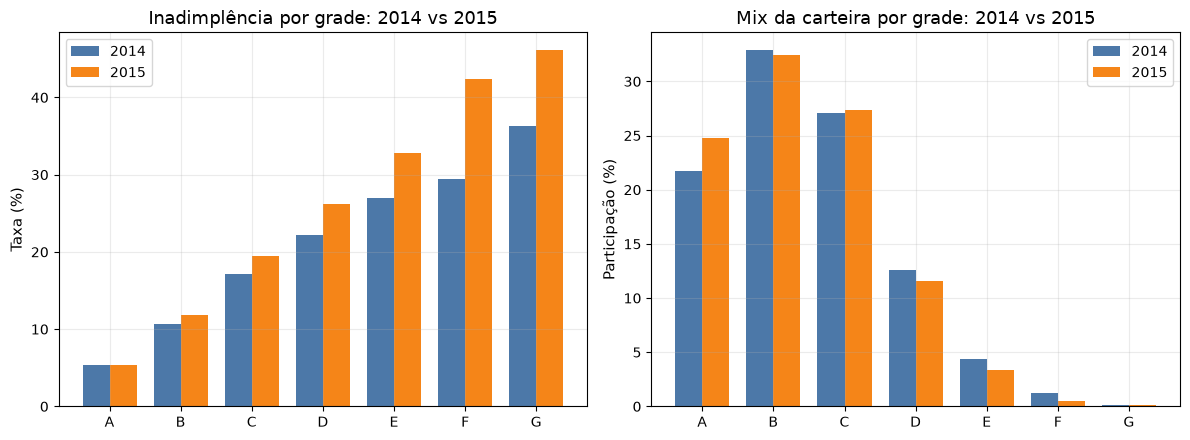

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

x = np.arange(len(eda_grade.index))
width = 0.38

axes[0].bar(
    x - width / 2,
    eda_grade["default_2014_pct"],
    width,
    label="2014",
    color="#4c78a8",
)
axes[0].bar(
    x + width / 2,
    eda_grade["default_2015_pct"],
    width,
    label="2015",
    color="#f58518",
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(eda_grade.index)
axes[0].set_title("Inadimplência por grade: 2014 vs 2015")
axes[0].set_ylabel("Taxa (%)")
axes[0].legend()

axes[1].bar(
    x - width / 2,
    eda_grade["share_2014_pct"],
    width,
    label="2014",
    color="#4c78a8",
)
axes[1].bar(
    x + width / 2,
    eda_grade["share_2015_pct"],
    width,
    label="2015",
    color="#f58518",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(eda_grade.index)
axes[1].set_title("Mix da carteira por grade: 2014 vs 2015")
axes[1].set_ylabel("Participação (%)")
axes[1].legend()

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "03_grade_default_and_mix.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


### Interpretação exploratória

Entre 2014-Q1 e 2015-Q4, a inadimplência geral sobe de **12,87%** para **14,82%**,
enquanto a participação de D/E cai de **14,93%** para **12,26%**. No mesmo período, a
inadimplência dentro de D/E sobe de **22,3%** para **29,2%**, e nas demais grades de
**11,2%** para **12,8%**. Em quase todas as grades, 2015 fica acima de 2014.

Isso já enfraquece o mecanismo alegado pelo Head de Risco: D/E de fato concentram mais
risco, mas a carteira não parece ter ficado mais concentrada nelas. O próximo passo é
testar formalmente essas diferenças e separar efeito de mix de efeito dentro dos grupos.


## 2. Teste de hipótese

**Pergunta.** A alta da inadimplência entre 2014 e 2015 é estatisticamente detectável?
E o mecanismo “aprovamos mais D/E” encontra suporte nos dados?

**Método.** Uso testes z de duas proporções (\(\alpha = 0{,}05\)), comparando 2015 com 2014:

| Teste | O que avalia |
|---|---|
| H1 | A inadimplência geral de 2015 é maior que a de 2014? |
| H2 | A participação de D/E mudou entre 2014 e 2015? |
| H3 | A inadimplência *dentro* de D/E aumentou? |
| H4 | A inadimplência nas demais grades também aumentou? |


In [8]:
def proportion_test(success_a, n_a, success_b, n_b, alternative="larger"):
    # Two-sample z-test for proportions. Group A vs group B.
    stat, pvalue = proportions_ztest(
        count=[success_a, success_b],
        nobs=[n_a, n_b],
        alternative=alternative,
    )
    p_a = success_a / n_a
    p_b = success_b / n_b
    return {
        "rate_a": p_a,
        "rate_b": p_b,
        "delta_pp": 100 * (p_a - p_b),
        "z_stat": stat,
        "p_value": pvalue,
        "reject_h0_5pct": bool(pvalue < 0.05),
    }


early = df[df["period"] == "2014"]
late = df[df["period"] == "2015"]

tests = pd.DataFrame(
    [
        {
            "test": "H1 — inadimplência geral subiu (2015 > 2014)",
            **proportion_test(
                late["default_flag"].sum(),
                len(late),
                early["default_flag"].sum(),
                len(early),
                alternative="larger",
            ),
        },
        {
            "test": "H2 — participação de D/E mudou entre 2014 e 2015",
            **proportion_test(
                late["is_grade_de"].sum(),
                len(late),
                early["is_grade_de"].sum(),
                len(early),
                alternative="two-sided",
            ),
        },
        {
            "test": "H3 — inadimplência em D/E subiu (2015 > 2014)",
            **proportion_test(
                late.loc[late["is_grade_de"], "default_flag"].sum(),
                int(late["is_grade_de"].sum()),
                early.loc[early["is_grade_de"], "default_flag"].sum(),
                int(early["is_grade_de"].sum()),
                alternative="larger",
            ),
        },
        {
            "test": "H4 — inadimplência nas demais grades subiu",
            **proportion_test(
                late.loc[~late["is_grade_de"], "default_flag"].sum(),
                int((~late["is_grade_de"]).sum()),
                early.loc[~early["is_grade_de"], "default_flag"].sum(),
                int((~early["is_grade_de"]).sum()),
                alternative="larger",
            ),
        },
    ]
)

tests.to_csv(TABLES_DIR / "hypothesis_tests.csv", index=False)
tests.style.format(
    {
        "rate_a": "{:.2%}",
        "rate_b": "{:.2%}",
        "delta_pp": "{:.2f}",
        "z_stat": "{:.2f}",
        "p_value": "{:.2e}",
    }
)


,test,rate_a,rate_b,delta_pp,z_stat,p_value,reject_h0_5pct
0,H1 — inadimplência geral subiu (2015 > 2014),14.89%,13.73%,1.16,10.60,1.55e-26,True
1,H2 — participação de D/E mudou entre 2014 e 2015,14.89%,16.96%,-2.07,-18.30,9.06e-75,True
2,H3 — inadimplência em D/E subiu (2015 > 2014),27.70%,23.42%,4.28,12.61,9.35e-37,True
3,H4 — inadimplência nas demais grades subiu,12.64%,11.75%,0.90,8.03,5.07e-16,True


### Por que decompor a variação?

Os testes acima respondem se D/E é mais arriscado e se o mix ou as taxas condicionais
mudaram, mas **não** quantificam quanto da alta da taxa total veio de mudança no mix
versus piora dentro dos grupos. Por isso, faço uma **decomposição sequencial da
variação da taxa total** (decomposição exata de composição e taxas, no estilo Oaxaca),
separando efeito de composição e efeitos internos:

$$
\Delta R =
\underbrace{(s_{15}-s_{14})(p^{DE}_{14}-p^{Other}_{14})}_{\text{composição}}
+ \underbrace{s_{15}(p^{DE}_{15}-p^{DE}_{14})}_{\text{taxa D/E}}
+ \underbrace{(1-s_{15})(p^{Other}_{15}-p^{Other}_{14})}_{\text{taxa demais}}
$$

Nesta formulação, o efeito de composição usa as taxas de 2014, e os efeitos internos
usam as participações de 2015.


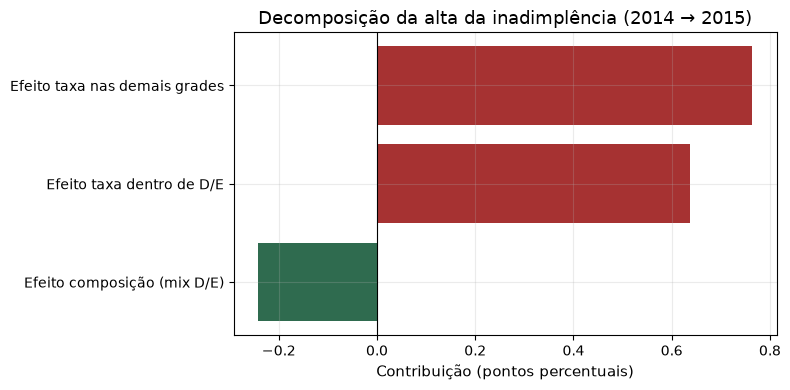

,component,pp
0,Variação total (2015 − 2014),1.1600
1,Efeito composição (mix D/E),-0.2410
2,Efeito taxa dentro de D/E,0.6380
3,Efeito taxa nas demais grades,0.7630
4,Soma dos efeitos,1.1600


In [9]:
s14 = early["is_grade_de"].mean()
s15 = late["is_grade_de"].mean()
p_de_14 = early.loc[early["is_grade_de"], "default_flag"].mean()
p_de_15 = late.loc[late["is_grade_de"], "default_flag"].mean()
p_ot_14 = early.loc[~early["is_grade_de"], "default_flag"].mean()
p_ot_15 = late.loc[~late["is_grade_de"], "default_flag"].mean()
r14 = early["default_flag"].mean()
r15 = late["default_flag"].mean()

composition = (s15 - s14) * (p_de_14 - p_ot_14)
rate_de = s15 * (p_de_15 - p_de_14)
rate_other = (1 - s15) * (p_ot_15 - p_ot_14)

decomp = pd.DataFrame(
    [
        {"component": "Variação total (2015 − 2014)", "pp": 100 * (r15 - r14)},
        {"component": "Efeito composição (mix D/E)", "pp": 100 * composition},
        {"component": "Efeito taxa dentro de D/E", "pp": 100 * rate_de},
        {"component": "Efeito taxa nas demais grades", "pp": 100 * rate_other},
        {
            "component": "Soma dos efeitos",
            "pp": 100 * (composition + rate_de + rate_other),
        },
    ]
)
decomp.to_csv(TABLES_DIR / "sequential_decomposition.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = decomp.iloc[1:4].copy()
colors = ["#2f6b4f" if v < 0 else "#a63232" for v in plot_df["pp"]]
ax.barh(plot_df["component"], plot_df["pp"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Contribuição (pontos percentuais)")
ax.set_title("Decomposição da alta da inadimplência (2014 → 2015)")
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "04_sequential_decomposition.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

decomp.round(3)


### Interpretação dos testes

A inadimplência de 2015 é significativamente maior que a de 2014
(\(p = 1{,}55 \times 10^{-26}\); +1,16 pp). A participação de D/E apresentou queda
estatisticamente detectável de 2,07 pp entre 2014 e 2015 (teste bilateral H2;
\(p < 0{,}001\)). Ao mesmo tempo, a inadimplência sobe dentro de D/E (+4,28 pp) e
também nas demais grades (+0,90 pp).

Na decomposição sequencial, o efeito de composição do mix D/E é **negativo**
(≈ −0,24 pp). A deterioração das taxas dentro dos grupos explica mais do que a alta
total observada (+0,64 pp em D/E e +0,76 pp nas demais grades, somando ≈ +1,40 pp). A
mudança favorável do mix D/E compensou aproximadamente 0,24 pp desse aumento, resultando
nos +1,16 pp observados na taxa total.

Os resultados não sustentam a explicação de que a inadimplência aumentou porque a
participação de D/E cresceu. Entre 2014 e 2015, o mix D/E diminuiu, enquanto a
inadimplência aumentou dentro de D/E e também nas demais grades. Isso sugere uma
deterioração mais ampla da qualidade das safras, que não é capturada apenas pelo mix
de grades.


## 3. Indo além — o que mais está associado à alta?

**Pergunta.** Se o mix D/E não explica a variação, o que mais mudou junto com a
inadimplência — e o que permanece associado à safra 2015 depois de ajustar por grade
e perfil observado?

**Método.** Estimo um logit com indicador de safra 2015, primeiro só com grade e depois
com DTI, FICO, renda e juros; em seguida, comparo variação de inadimplência e de juros
médios por grade, e o deslocamento do mix por faixa de DTI.


In [10]:
model_df = df.dropna(
    subset=[
        "default_flag",
        "debt_to_income_ratio",
        "fico_score_avg",
        "annual_income",
        "interest_rate_pct",
        "grade",
    ]
).copy()
model_df["late"] = (model_df["period"] == "2015").astype(int)
model_df["log_income"] = np.log1p(model_df["annual_income"])

logit_basic = smf.logit(
    "default_flag ~ late + C(grade)",
    data=model_df,
).fit(disp=False)

logit_full = smf.logit(
    "default_flag ~ late + C(grade) + debt_to_income_ratio"
    " + fico_score_avg + log_income + interest_rate_pct",
    data=model_df,
).fit(disp=False)

def odds_ratio_row(model, label):
    coef = model.params["late"]
    se = model.bse["late"]
    or_point = np.exp(coef)
    or_low = np.exp(coef - 1.96 * se)
    or_high = np.exp(coef + 1.96 * se)
    p_value = model.pvalues["late"]
    return {
        "model": label,
        "late_coefficient": coef,
        "odds_ratio_2015": or_point,
        "or_ci95_low": or_low,
        "or_ci95_high": or_high,
        "p_value": p_value,
        "p_value_display": (
            f"{p_value:.2e}" if p_value >= 1e-300 else "<1e-300"
        ),
        "pseudo_r2": model.prsquared,
        "n_obs": int(model.nobs),
    }


logit_results = pd.DataFrame(
    [
        odds_ratio_row(logit_basic, "Grade only"),
        odds_ratio_row(logit_full, "Grade + borrower controls"),
    ]
)
logit_results.to_csv(TABLES_DIR / "logit_vintage_effect.csv", index=False)

print(
    "Leitura (modelo com controles): após ajuste pelas características observadas, "
    "os empréstimos originados em 2015 apresentaram odds de inadimplência "
    f"aproximadamente {100 * (logit_results.loc[1, 'odds_ratio_2015'] - 1):.0f}% "
    "maiores que os de 2014 "
    f"(OR={logit_results.loc[1, 'odds_ratio_2015']:.2f}; "
    f"IC95% "
    f"{logit_results.loc[1, 'or_ci95_low']:.2f}–"
    f"{logit_results.loc[1, 'or_ci95_high']:.2f})."
)
print(
    "O modelo é associativo, não causal, e pode haver variáveis não observadas."
)

logit_results[
    [
        "model",
        "odds_ratio_2015",
        "or_ci95_low",
        "or_ci95_high",
        "p_value_display",
        "pseudo_r2",
        "n_obs",
    ]
]


Leitura (modelo com controles): após ajuste pelas características observadas, os empréstimos originados em 2015 apresentaram odds de inadimplência aproximadamente 27% maiores que os de 2014 (OR=1.27; IC95% 1.25–1.29).
O modelo é associativo, não causal, e pode haver variáveis não observadas.


,model,odds_ratio_2015,or_ci95_low,or_ci95_high,p_value_display,pseudo_r2,n_obs
0,Grade only,1.1692,1.1484,1.1904,2.34e-65,0.0527,445594
1,Grade + borrower controls,1.2697,1.2453,1.2947,9.55e-128,0.0610,445594


In [11]:
print(logit_full.summary().as_text())


                           Logit Regression Results                           
Dep. Variable:           default_flag   No. Observations:               445594
Model:                          Logit   Df Residuals:                   445582
Method:                           MLE   Df Model:                           11
Date:                Tue, 28 Jul 2026   Pseudo R-squ.:                 0.06104
Time:                        13:06:39   Log-Likelihood:            -1.7291e+05
converged:                       True   LL-Null:                   -1.8415e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                1.2761      0.176      7.248      0.000       0.931       1.621
C(grade)[T.B]            0.2449      0.022     11.250      0.000       0.202       0.288
C(grade)[T.C

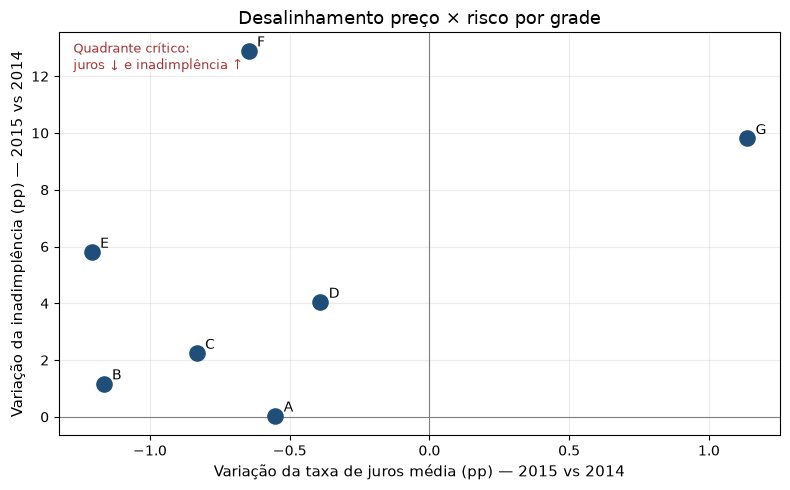

,delta_default_pp,delta_rate_pp,dti_2014,dti_2015,delta_dti
grade,,,,,
A,0.0400,-0.5500,15.8100,16.2900,0.4800
B,1.1700,-1.1700,17.1200,17.9800,0.8600
C,2.2500,-0.8300,18.4100,19.6500,1.2400
D,4.0500,-0.3900,19.1500,20.8100,1.6600
E,5.8100,-1.2100,19.1800,21.2900,2.1100
F,12.9000,-0.6500,18.5000,21.1400,2.6400
G,9.8100,1.1400,20.0100,21.9900,1.9800


In [12]:
pricing = eda_grade[
    ["delta_default_pp", "delta_rate_pp", "dti_2014", "dti_2015"]
].copy()
pricing["delta_dti"] = pricing["dti_2015"] - pricing["dti_2014"]
pricing.to_csv(TABLES_DIR / "pricing_vs_risk_by_grade.csv")

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)
ax.scatter(
    pricing["delta_rate_pp"],
    pricing["delta_default_pp"],
    s=120,
    color="#1f4e79",
    zorder=3,
)
for grade, row in pricing.iterrows():
    ax.annotate(
        grade,
        (row["delta_rate_pp"] + 0.03, row["delta_default_pp"] + 0.15),
    )

ax.set_xlabel("Variação da taxa de juros média (pp) — 2015 vs 2014")
ax.set_ylabel("Variação da inadimplência (pp) — 2015 vs 2014")
ax.set_title("Desalinhamento preço × risco por grade")
ax.text(
    0.02,
    0.98,
    "Quadrante crítico:\njuros ↓ e inadimplência ↑",
    transform=ax.transAxes,
    va="top",
    fontsize=9,
    color="#a63232",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_pricing_vs_risk.png", dpi=150, bbox_inches="tight")
plt.show()

pricing.round(2)


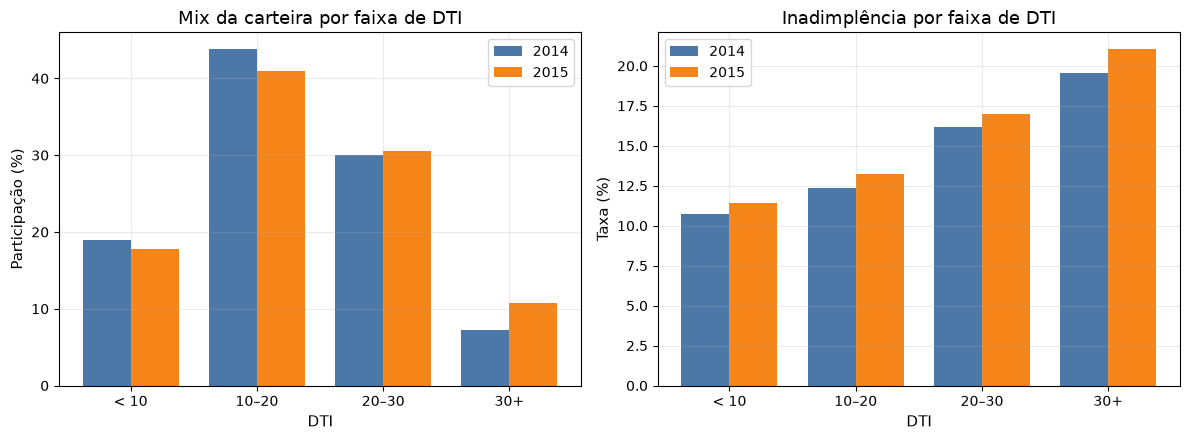

,period,dti_band,portfolio_share,default_rate,portfolio_share_pct,default_rate_pct
3,2014,< 10,30853,0.1072,18.9783,10.7186
7,2015,< 10,50439,0.1141,17.8213,11.4098
0,2014,10–20,71218,0.1238,43.8076,12.3803
4,2015,10–20,115815,0.1321,40.9203,13.2081
1,2014,20–30,48797,0.1619,30.0160,16.1936
5,2015,20–30,86521,0.1701,30.5700,17.0051
2,2014,30+,11702,0.1956,7.1981,19.5608
6,2015,30+,30249,0.2105,10.6877,21.0453


In [13]:
dti_shift = (
    df.groupby(["period", "dti_band"], as_index=False)
    .agg(
        portfolio_share=("loan_id", "size"),
        default_rate=("default_flag", "mean"),
    )
)
totals = dti_shift.groupby("period")["portfolio_share"].transform("sum")
dti_shift["portfolio_share_pct"] = 100 * dti_shift["portfolio_share"] / totals
dti_shift["default_rate_pct"] = 100 * dti_shift["default_rate"]
dti_shift = dti_shift[dti_shift["dti_band"] != "Unknown"]

order = ["< 10", "10–20", "20–30", "30+"]
dti_shift["dti_band"] = pd.Categorical(
    dti_shift["dti_band"],
    categories=order,
    ordered=True,
)
dti_shift = dti_shift.sort_values(["dti_band", "period"])
dti_shift.to_csv(TABLES_DIR / "dti_band_shift.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(order))
width = 0.38

for ax, metric, title, ylabel in [
    (axes[0], "portfolio_share_pct", "Mix da carteira por faixa de DTI", "Participação (%)"),
    (axes[1], "default_rate_pct", "Inadimplência por faixa de DTI", "Taxa (%)"),
]:
    vals_2014 = [
        dti_shift.loc[
            (dti_shift["period"] == "2014") & (dti_shift["dti_band"] == band),
            metric,
        ].iloc[0]
        for band in order
    ]
    vals_2015 = [
        dti_shift.loc[
            (dti_shift["period"] == "2015") & (dti_shift["dti_band"] == band),
            metric,
        ].iloc[0]
        for band in order
    ]
    ax.bar(x - width / 2, vals_2014, width, label="2014", color="#4c78a8")
    ax.bar(x + width / 2, vals_2015, width, label="2015", color="#f58518")
    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("DTI")
    ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_dti_shift.png", dpi=150, bbox_inches="tight")
plt.show()

dti_shift


## 4. Resultado adicional — pricing e qualidade dentro da grade

**Resultado.** Entre as grades B e F, a safra de 2015 apresentou inadimplência maior,
apesar de taxas de juros médias menores. No mesmo período, o DTI médio aumentou dentro
de várias grades (por exemplo, D e E). No modelo com controles observados, a safra 2015
permanece associada a odds de inadimplência cerca de **27% maiores** que 2014
(OR ≈ 1,27; IC95% na tabela acima).

**Interpretação.** Esse padrão merece revisão porque sugere que o aumento do risco
realizado não foi acompanhado por aumento proporcional do preço — sem afirmar que a
precificação *causou* a inadimplência. O aumento do DTI dentro das mesmas grades sugere
que a qualidade do perfil pode ter se deteriorado sem ser totalmente refletida pela
classificação. O residual da safra no logit é associativo, não causal, e pode haver
variáveis não observadas.

Em conjunto com os testes anteriores, os resultados não sustentam a explicação de que a
inadimplência aumentou porque a participação de D/E cresceu. A leitura mais consistente
com a evidência disponível é uma deterioração mais ampla da qualidade das safras, com
sinais de desalinhamento entre pricing e risco realizado.


## 5. Recomendação ao negócio

Com base nos resultados — e não em um corte automático de D/E — as ações mais
prudentes são:

1. **Revisar calibração e regras de aprovação**, não apenas o volume de D/E.
   Restringir D/E sem olhar o risco dentro de C/D pode deslocar o problema para outras
   etiquetas.
2. **Monitorar DTI alto.** A participação da faixa 30+ cresceu de 7,2% para 10,7% da
   carteira, enquanto sua inadimplência aumentou de 19,6% para 21,0%.
3. **Revisitar pricing onde risco subiu e juros caíram (B–F)**, priorizando C/D/E, para
   checar se a precificação está acompanhando o risco realizado.
4. **Acompanhar no dashboard** a inadimplência *dentro* da grade e o gap preço×risco —
   além do mix D/E — usando a mesma coorte Gold já publicada no Looker.

**Síntese para o Head de Risco.** A inadimplência da coorte 2014–2015 subiu de forma
detectável, mas os dados não sustentam a explicação de que isso ocorreu porque a
participação de D/E aumentou. A alta está associada a piora dentro das faixas de risco,
com aumento de DTI e sinais de desalinhamento entre preço e risco realizado. O caminho
mais útil é recalibrar underwriting e pricing com monitoramento condicional à grade —
não um corte cego de D/E.


## 6. Limitações

- A análise é observacional e identifica associações, não relações causais.
- O escopo está restrito a empréstimos de 36 meses originados em 2014–2015 e com
  desfecho conhecido.
- Grade e taxa de juros são variáveis fortemente relacionadas; seus coeficientes
  individuais no modelo ajustado não devem ser interpretados isoladamente como efeitos
  causais.
- Mudanças macroeconômicas, operacionais ou de política de crédito não observadas podem
  explicar parte do efeito associado à safra de 2015.


## Uso de ferramentas de IA

Foi utilizado o agente GPT-5.6 Sol (Cursor) para acelerar a estruturação inicial
do código, a organização do notebook e a revisão de linguagem. O escopo analítico,
as definições das métricas, os métodos estatísticos, a validação dos resultados e as
conclusões finais foram revisados e aprovados pelo autor.
